# 2 - Explore Distributions

One-dimensional EDA on the outcome variable. Histograms, summary stats, and a boxplot. Goal: confirm life expectancy is roughly normally distributed across counties (so linear regression is appropriate) and look for outliers.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
df = pd.read_csv('data/county_outcomes.csv')
df.describe().round(2)

,fips,life_expectancy
count,3070.00,3070.00
mean,30361.27,75.75
std,15159.71,3.43
min,1001.00,55.92
25%,18173.50,73.57
50%,29144.00,75.84
75%,45068.50,77.99
max,56045.00,98.90


### Histogram of life expectancy

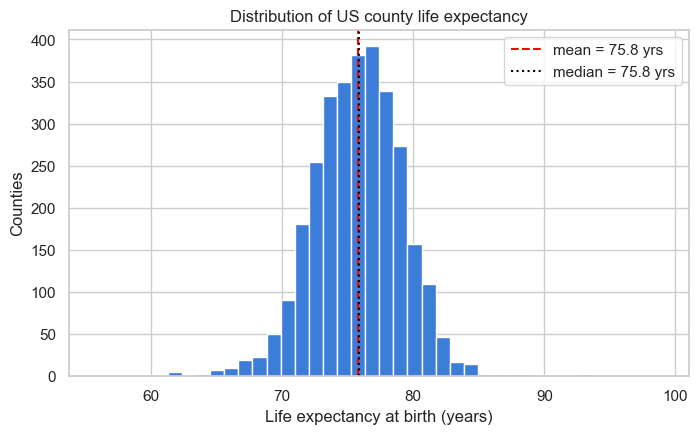

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df['life_expectancy'], bins=40, color='#3b7dd8', edgecolor='white')
ax.axvline(df['life_expectancy'].mean(), color='red', linestyle='--',
           label=f"mean = {df['life_expectancy'].mean():.1f} yrs")
ax.axvline(df['life_expectancy'].median(), color='black', linestyle=':',
           label=f"median = {df['life_expectancy'].median():.1f} yrs")
ax.set_xlabel('Life expectancy at birth (years)')
ax.set_ylabel('Counties')
ax.set_title('Distribution of US county life expectancy')
ax.legend()
plt.show()

### Boxplot

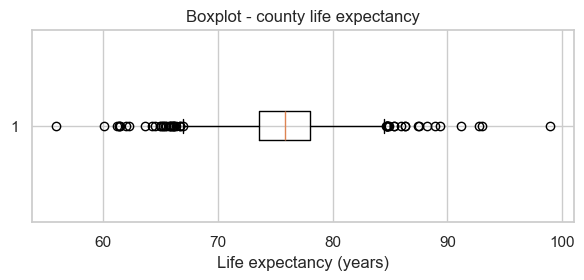

In [8]:
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.boxplot(df['life_expectancy'].dropna(), vert=False)
ax.set_xlabel('Life expectancy (years)')
ax.set_title('Boxplot - county life expectancy')
plt.show()

### Top and bottom counties

In [9]:
print('Lowest life expectancy:')
print(df.nsmallest(10, 'life_expectancy')[['county_name','state_name','life_expectancy']].to_string(index=False))
print()
print('Highest life expectancy:')
print(df.nlargest(10, 'life_expectancy')[['county_name','state_name','life_expectancy']].to_string(index=False))

Lowest life expectancy:
         county_name   state_name  life_expectancy
      Buffalo County South Dakota        55.918958
Oglala Lakota County South Dakota        60.104939
    Roosevelt County      Montana        61.173395
         Todd County South Dakota        61.355813
        Dewey County South Dakota        61.360466
       Corson County South Dakota        61.424064
        Sioux County North Dakota        62.017619
       Benson County North Dakota        62.222332
      Kingman County       Kansas        63.615230
     Thurston County     Nebraska        64.220479

Highest life expectancy:
         county_name   state_name  life_expectancy
         Mono County   California        98.902938
       Summit County     Colorado        93.001848
       Pitkin County     Colorado        92.724934
       Oliver County North Dakota        91.152649
      Liberty County      Montana        89.370616
        Eagle County     Colorado        88.908523
   San Miguel County     Colorad